Research Question: Why are Claudin 10b and Claudin 16/19 seperated in the kidney (they have very different permeabilities for Na+ and Mg2+)?

In [178]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

Using **Nernst-Equation** the EMF for the individual ions at each boundary is calculated

In [179]:
def nernst_equation(R, T, F, z, C_start, C_end, ion_name):
    if C_start <= 0 or C_end <= 0:
        raise ValueError(
            f"Non-positive concentration for {ion_name}: "
            f"C_start={C_start:.6f}, C_end={C_end:.6f}"
        )
    
    return ((R * T) / (F * z)) * math.log(C_start / C_end)

Using **Goldman-Equation** the equilibrium potential is calculated for each boundary:

In [180]:
# works only for monovalent ions such as Na+ or Cl-

def goldmann_equation(R, T, F, P_Na, P_Cl, Na_L, Cl_L, Na_R, Cl_R):
    # For Na: A positive EMF → Positive Flux (A to B).
    # For Cl: A positive EMF → Negative Flux (B to A).
    epsilon = 1e-15
    numerator = (P_Na * Na_L) + (P_Cl * Cl_R) + epsilon
    denominator = (P_Na * Na_R) + (P_Cl * Cl_L) + epsilon

    #print(f"Numerator: {numerator}\nDenominator: {denominator}")
    return (R * T / F) * math.log(numerator / denominator)

Extend Goldman-Equation to divalent ions

In [181]:
# math domain error in -np.sqrt version, which is the 2nd solution of the numerical problem
def divalent_membrane_potential(P_Mg, P_Na, P_Cl, a_Mg_bl, a_Mg_ap, a_Na_bl, a_Na_ap, a_Cl_bl, a_Cl_ap, R, T, F):
    u = math.log((np.sqrt((P_Na * a_Na_bl - P_Na * a_Na_ap - P_Cl * a_Cl_bl + P_Cl * a_Cl_ap)**2 - 4 * (4 * P_Mg * a_Mg_bl + P_Na * a_Na_bl + P_Cl * a_Cl_ap) * 
                            (-4 * P_Mg * a_Mg_ap - P_Na * a_Na_ap - P_Cl * a_Cl_bl)) - P_Na * a_Na_bl + P_Na * a_Na_ap + P_Cl * a_Cl_bl - P_Cl * a_Cl_ap) / 
                            (2 * (4 * P_Mg * a_Mg_bl + P_Na * a_Na_bl + P_Cl * a_Cl_ap)))
    #print(f"u: {u}\n")
    membrane_pot = u * R * T / F    # in V 
    return membrane_pot


In [182]:
def EMF(equilibrium_pot, nernst_pot):
    """
    equilibrium_pot: The voltage at the boundary (from Goldman equation).
    nernst_pot: The equilibrium potential for a specific ion.
    """
    return nernst_pot - equilibrium_pot     # e.g. if nernst_pot +60mV for Na+ and equilirium_pot -70, this will result in 130mV, which means that there is a strong pull for Na ions from apical to basolateral

Flux is proportional to EMF, permeability and the concentration in the donor compartment

In [183]:
def calculate_flux(emf, p, z, start_comp, end_comp, ion_name):
    C_start = start_comp.concentrations[ion_name]
    C_end = end_comp.concentrations[ion_name]
    # Threshold changed from 1 to 0!!!
    if emf * p * z > 0: # ions move from apical to basolateral
        return emf * p * z * C_start
    else:   # ions move from basolateral to apical
        return emf * p * z * C_end

Using Flux, the **new number of ions** is calculated

In [184]:
from scipy.constants import Avogadro, gas_constant as R, physical_constants
F = physical_constants["Faraday constant"][0]

def calculate_ion_change(flux, vol_liters, dt):
    # Change in ion count after 1 step
    ion_change = flux * dt * vol_liters * Avogadro
    return ion_change

For parallel connected tight junctions that have different potentials, we have to calculate a shared voltage U_k

In [185]:
def shared_voltage(U1, U2, R1, R2):
    # calculate equalization current
    I_a = (U1 - U2) / (R1 + R2)
    # calculate shared terminal voltage
    U_k = U1 - I_a * R1
    
    return U_k

In [186]:
class Compartment:
    def __init__(self, name, na_conc, cl_conc, mg_conc=0):
        self.name = name
        self.concentrations = {'Na': na_conc, 'Cl': cl_conc, 'Mg': mg_conc}

    def get_ion_counts(self, ion_conc, volume, avogadro):
        return ion_conc * volume * avogadro


In [187]:
class Junctions:
    def __init__(self, comp_apical:Compartment, comp_basolateral:Compartment, p_na, p_cl, p_mg, voltage_clamp: float=None):
        self.apical = comp_apical    # A Compartment object
        self.basolateral = comp_basolateral  # A Compartment object

        self.permeabilities = {'Na': p_na, 'Cl': p_cl, 'Mg': p_mg}

        self.voltage_clamp = voltage_clamp  # to apply voltage clamp to a junction, set it while initializing the Junction object

    def calculate_potentials(self, R, T, F, divalent=False):
        if self.voltage_clamp is not None:
            return self.voltage_clamp 
        # Access concentrations directly from the Compartment objects
        # l: apical, r: basolateral
        c_na_l = self.apical.concentrations['Na']
        c_na_r = self.basolateral.concentrations['Na']
        c_cl_l = self.apical.concentrations['Cl']
        c_cl_r = self.basolateral.concentrations['Cl']
        c_mg_l = self.apical.concentrations['Mg']
        c_mg_r = self.basolateral.concentrations['Mg']

        if divalent:
            membrane_pot = divalent_membrane_potential(self.permeabilities['Mg'], self.permeabilities['Na'], self.permeabilities['Cl'],
                                                       c_mg_r, c_mg_l, c_na_r, c_na_l, c_cl_r, c_cl_l, R, T, F)
        else:
            membrane_pot = goldmann_equation(R, T, F, self.permeabilities['Na'], self.permeabilities['Cl'],
                                            c_na_l, c_cl_l, c_na_r, c_cl_r)
        
        return membrane_pot
    
    def calculate_fluxes(self, R, T, F, ion_list, membrane_pot, dt, volume):
        """
        Returns ion count change
        """
        ion_count_changes = {}
        
        for ion in ion_list:
            p = self.permeabilities[ion]
            if ion == 'Na':
                z = 1
            elif ion == 'Cl':
                z = -1
            else:
                z = 2
            
            C_l = self.apical.concentrations[ion]
            C_r = self.basolateral.concentrations[ion]
            
            # Nernst + Membrane Pot. -> EMF -> flux
            nernst = nernst_equation(R, T, F, z, C_l, C_r, ion)
            emf = EMF(membrane_pot, nernst)
            flux = calculate_flux(emf, p, z, self.apical, self.basolateral, ion)
            
            # Convert flux to molar change
            ion_count_changes[ion] = calculate_ion_change(flux, volume, dt)
            
        return ion_count_changes

In [188]:
# Volume of TJ compartments
volume = 8e-20  # liters

# time step
dt = 0.0001  # s
total_time_steps = 1000000

# Temp
TEMP = 310  # 37 celcius in Kelvin

In [189]:
# Permeabilities

# Cldn10b: PNa:PCl = 10 : 1; PMg : PCl = 3 : 1
# Cldn16+19: PNa:PCl = 2.5 : 1; PMg : PCl = 8.5 : 1

P_Cl = 1   # baseline

P_Na_10b = 10
P_Mg_10b = 3

P_Na_16_19 = 2.5
P_Mg_16_19 = 8.5

# we don't divide by 2 when calculating the average because we compare Cldn10b + Cldn16/19 to 2 * CldnAVG
P_Na_avg = (P_Na_10b + P_Na_16_19)
P_Mg_avg = (P_Mg_10b + P_Mg_16_19) 
P_Cl_avg = P_Cl * 2
 

In [190]:
# Resistances for Kidney tubule from DOI: 10.1016/j.kint.2017.08.029
R_10b = 14
R_16_19 = 19

To switch to **divalent** mode:

1. Add Magnesium concentration when initializing compartments.
2. Change the "divalent" input param of the "calculate_potentials" function to True.
3. Add 'Mg' to the ion_list param in the "calculate_fluxes" function.

In [191]:
# 1 or 2
STATE = 2
# "parallel" or "avg"
SIMULATION_MODE = "parallel"

# Initialize Compartments and Junctions
if STATE == 1:
    # ---------- STATE 1: Early TAL ----------
    # A: apical, high luminal concentrations (medullary side)
    # D: basolateral, plasma; fixed, physiological
    # B, C: Tight Junction compartments, start at basolateral values, will evolve freely
    comp_a = Compartment('A', na_conc=250, cl_conc=233, mg_conc=2.0) # apical
    comp_b = Compartment('B', na_conc=145, cl_conc=105, mg_conc=0.5) # TJ
    comp_c = Compartment('C', na_conc=145, cl_conc=105, mg_conc=0.5) # TJ
    comp_d = Compartment('D', na_conc=145, cl_conc=105, mg_conc=0.5) # basolateral

    # Voltage clamp of 9 mV on the A|B junction only (active transcellular pump contribution)
    V_CLAMP_STATE1 = -0.009  # in Volts, represents the 5–13 mV lumen-positive potential

    junc_a_b = Junctions(comp_a, comp_b, P_Na_10b, P_Cl, P_Mg_10b, voltage_clamp=V_CLAMP_STATE1/3)  # to activate voltage clamp, give it as an input when initializing Junctions
    junc_b_c = Junctions(comp_b, comp_c, P_Na_10b, P_Cl, P_Mg_10b, voltage_clamp=V_CLAMP_STATE1/3)
    junc_c_d = Junctions(comp_c, comp_d, P_Na_10b, P_Cl, P_Mg_10b, voltage_clamp=V_CLAMP_STATE1/3)

    junctions = [junc_a_b, junc_b_c, junc_c_d]

elif STATE == 2:
    # ---------- STATE 2: End of TAL ----------
    # A: apical, dilute luminal concentrations because of active NaCl reabsorption (cortical side)
    # B, C, D same as State 1
    # No voltage clamp, potential comes from concentration gradients alone
    comp_a = Compartment('A', na_conc=50, cl_conc=45, mg_conc=0.2) # apical
    comp_b = Compartment('B', na_conc=145, cl_conc=105, mg_conc=0.5) # TJ
    comp_c = Compartment('C', na_conc=145, cl_conc=105, mg_conc=0.5) # TJ
    comp_d = Compartment('D', na_conc=145, cl_conc=105, mg_conc=0.5) # basolateral

    # "parallel" simulation mode calculates fluxes through Cldn10b and Cldn16/19 in parallel and "avg" calculates with a single averaged claudin typewith double permeabilities for fair comparison
    if SIMULATION_MODE == "parallel":
        # Neither claudin type is clamped here -- both must be free to compute their own
        # equilibrium potential from their own permeabilities. run_simulation() combines
        # them into a shared voltage U_k (resistance-weighted) fresh every timestep.
        junc_a_b_10b = Junctions(comp_a, comp_b, P_Na_10b, P_Cl, P_Mg_10b)
        junc_b_c_10b = Junctions(comp_b, comp_c, P_Na_10b, P_Cl, P_Mg_10b)
        junc_c_d_10b = Junctions(comp_c, comp_d, P_Na_10b, P_Cl, P_Mg_10b)

        junc_a_b_16_19 = Junctions(comp_a, comp_b, P_Na_16_19, P_Cl, P_Mg_16_19)
        junc_b_c_16_19 = Junctions(comp_b, comp_c, P_Na_16_19, P_Cl, P_Mg_16_19)
        junc_c_d_16_19 = Junctions(comp_c, comp_d, P_Na_16_19, P_Cl, P_Mg_16_19)

        junctions_10b = [junc_a_b_10b, junc_b_c_10b, junc_c_d_10b]
        junctions_16_19 = [junc_a_b_16_19, junc_b_c_16_19, junc_c_d_16_19]

    elif SIMULATION_MODE == "avg":
        junc_a_b_avg = Junctions(comp_a, comp_b, P_Na_avg, P_Cl_avg, P_Mg_avg) 
        junc_b_c_avg = Junctions(comp_b, comp_c, P_Na_avg, P_Cl_avg, P_Mg_avg) 
        junc_c_d_avg = Junctions(comp_c, comp_d, P_Na_avg, P_Cl_avg, P_Mg_avg) 

        junctions_avg = [junc_a_b_avg, junc_b_c_avg, junc_c_d_avg]

    else:
        raise ValueError(f"Invalid SIMULATION_MODE: {SIMULATION_MODE}! Expected 'parallel' or 'avg'.")
    
else:
    raise ValueError(f"Invalid STATE: {STATE}! Expected 1 or 2.")


compartments = [comp_a, comp_b, comp_c, comp_d]

In [ ]:
def run_simulation(compartments, junctions_10b, junctions_16_19=None, R_10b=None, R_16_19=None):
    """
    Runs the main simulation loop.
    If junctions_16_19 is None, runs single-claudin mode with averaged permeabilities of Cldn10b and Cldn16/19.
    If junctions_16_19 is provided, runs parallel mode (10b + 16/19).
    Returns flow_history_10b, flow_history_16_19, potential_history_10b, potential_history_16_19, history, time_axis.
    """
    flow_history_10b = {f"{j.apical.name}->{j.basolateral.name}": {ion: [] for ion in ['Na', 'Cl', 'Mg']} for j in junctions_10b}   # in single-claudin mode this is for averaged claudin even though its named 10b
    flow_history_16_19 = {f"{j.apical.name}->{j.basolateral.name}": {ion: [] for ion in ['Na', 'Cl', 'Mg']} for j in junctions_16_19} if junctions_16_19 else None

    potential_history_10b  = {f"{j.apical.name}->{j.basolateral.name}": [] for j in junctions_10b}
    potential_history_16_19 = {f"{j.apical.name}->{j.basolateral.name}": [] for j in junctions_16_19} if junctions_16_19 else None
    history   = {comp.name: {ion: [] for ion in ['Na', 'Cl', 'Mg']} for comp in compartments}
    time_axis = []

    for t in range(total_time_steps):
        time_axis.append(t * dt)

        # save compartment concentrations
        for comp in compartments:
            for ion in ['Na', 'Cl', 'Mg']:
                history[comp.name][ion].append(comp.concentrations[ion])

        deltas = {comp.name: {'Na': 0.0, 'Cl': 0.0, 'Mg': 0.0} for comp in compartments}

        # compute 10b and 16/19 potentials and compute shared voltage, then clamp both junctions to this value; if 16/19 is given
        if junctions_16_19:
            for j_10b, j_16_19 in zip(junctions_10b, junctions_16_19):
                j_10b.voltage_clamp = None
                j_16_19.voltage_clamp = None
                U1 = j_10b.calculate_potentials(R, TEMP, F, divalent=True)
                U2 = j_16_19.calculate_potentials(R, TEMP, F, divalent=True)

                U_k = shared_voltage(U1, U2, R_10b, R_16_19)
                j_10b.voltage_clamp = U_k
                j_16_19.voltage_clamp = U_k

        # compute fluxes for both claudin types and accumulate deltas
        # first loop 10b, then 16/19 if given
        junc_sets = [(junctions_10b, flow_history_10b, potential_history_10b)]
        if junctions_16_19:
            junc_sets.append((junctions_16_19, flow_history_16_19, potential_history_16_19))

        for junctions, flow_hist, pot_hist in junc_sets:
            for j in junctions:
                membrane_pot = j.calculate_potentials(R, TEMP, F, divalent=True)
                pot_hist[f"{j.apical.name}->{j.basolateral.name}"].append(-membrane_pot * 1000)
                changes = j.calculate_fluxes(R, TEMP, F, ['Na', 'Cl', 'Mg'], membrane_pot, dt, volume)
                for ion, amount in changes.items():
                    conc_change = amount / (Avogadro * volume)
                    deltas[j.apical.name][ion]  -= conc_change
                    deltas[j.basolateral.name][ion] += conc_change
                    flow_hist[f"{j.apical.name}->{j.basolateral.name}"][ion].append(amount)

        # update B and C with changes that come from both junction types
        for comp in compartments:
            if comp.name not in ['A', 'D']:
                for ion in ['Na', 'Cl', 'Mg']:
                    comp.concentrations[ion] += deltas[comp.name][ion]

    return flow_history_10b, flow_history_16_19, potential_history_10b, potential_history_16_19, history, time_axis

        

# if STATE == 1:
#     flow_history = {f"{j.apical.name}->{j.basolateral.name}": {ion: [] for ion in ['Na', 'Cl', 'Mg']} for j in junctions}
#     potential_history = {f"{j.apical.name}->{j.basolateral.name}": [] for j in junctions}
#     history = {comp.name: {ion: [] for ion in ['Na', 'Cl', 'Mg']} for comp in compartments}
#     time_axis = []

#     for t in range(total_time_steps):
#         time_axis.append(t * dt)
#         for comp in compartments:
#             for ion in ['Na', 'Cl', 'Mg']:
#                 history[comp.name][ion].append(comp.concentrations[ion])

#         deltas = {comp.name: {'Na': 0.0, 'Cl': 0.0, 'Mg': 0.0} for comp in compartments}

#         for j in junctions:
#             membrane_pot = j.calculate_potentials(R, TEMP, F, divalent=True)
#             potential_history[f"{j.apical.name}->{j.basolateral.name}"].append(membrane_pot * 1000)
#             changes = j.calculate_fluxes(R, TEMP, F, ['Na', 'Cl', 'Mg'], membrane_pot, dt, volume)
#             for ion, amount in changes.items():
#                 conc_change = amount / (Avogadro * volume)
#                 deltas[j.apical.name][ion]  -= conc_change
#                 deltas[j.basolateral.name][ion] += conc_change
#                 flow_history[f"{j.apical.name}->{j.basolateral.name}"][ion].append(amount)

#         for comp in compartments:
#             if comp.name not in ['A', 'D']:
#                 for ion in ['Na', 'Cl', 'Mg']:
#                    comp.concentrations[ion] += deltas[comp.name][ion]

In [193]:
# Run the simulation
if STATE == 1:
    flow_history_10b, _, potential_history_10b, _, history, time_axis = run_simulation(compartments, junctions)

elif STATE == 2:
    if SIMULATION_MODE == "parallel":
        flow_history_10b, flow_history_16_19, potential_history_10b, potential_history_16_19, history, time_axis = run_simulation(compartments, junctions_10b, junctions_16_19, R_10b, R_16_19)
        # store for Mg comparison later
        saved_parallel = (flow_history_10b, flow_history_16_19, time_axis)

    elif SIMULATION_MODE == "avg":
        flow_history_avg, _, potential_history_avg, _, history, time_axis = run_simulation(compartments, junctions_avg)
        saved_avg = (flow_history_avg, time_axis)
        

10b pot: -0.024122266072102744
16/19 pot: -0.015179775489123115


KeyboardInterrupt: 

In [ ]:
def plot_ion_dynamics(history, time_axis):
    """
    Plots Na+, Cl-, and Mg2+ concentrations for all compartments.
    """
    # Create a figure with 3 vertical subplots
    fig, (ax_na, ax_cl, ax_mg) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # 1: Sodium Concentrations
    for comp_name, ions in history.items():
        ax_na.plot(time_axis, ions['Na'], label=f'Na+ {comp_name}')
    ax_na.set_ylabel('Na+ (mol/L)')
    ax_na.set_title('Sodium Concentration Profile')
    ax_na.legend(loc='center right', fontsize='small')
    ax_na.grid(True, alpha=0.3)

    # 2: Chloride Concentrations
    for comp_name, ions in history.items():
        ax_cl.plot(time_axis, ions['Cl'], label=f'Cl- {comp_name}')
    ax_cl.set_ylabel('Cl- (mol/L)')
    ax_cl.set_title('Chloride Concentration Profile')
    ax_cl.legend(loc='center right', fontsize='small')
    ax_cl.grid(True, alpha=0.3)

    # 3: Magnesium Concentrations
    for comp_name, ions in history.items():
        ax_mg.plot(time_axis, ions['Mg'], label=f'Mg2+ {comp_name}')
    ax_mg.set_ylabel('Mg2+ (mol/L)')
    ax_mg.set_xlabel('Time (a.u.)')
    ax_mg.set_title('Magnesium Concentration Profile')
    ax_mg.legend(loc='center right', fontsize='small')
    ax_mg.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f"figures/state_{STATE}_concentrations.png")
    plt.show()

In [ ]:
def plot_flow_dynamics(flow_history, time_axis, title=None):
    """
    Plots the net movement (flux * dt) of ions between junctions.
    """
    # Create a figure with 3 vertical subplots
    fig, (ax_na, ax_cl, ax_mg) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    # optional super-title
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold")

    # Panel 1: Sodium Flow
    for j_name, ions in flow_history.items():
        ax_na.plot(time_axis, ions['Na'], label=f'Flow {j_name}')
    ax_na.set_ylabel('Na+ Net Flow (arbitrary unit)')
    ax_na.set_title('Sodium Flow Rate Between Compartments')
    ax_na.axhline(0, color='black', lw=1, ls='--') 
    ax_na.legend(loc='upper right', fontsize='small')
    ax_na.grid(True, alpha=0.3)

    # Panel 2: Chloride Flow
    for j_name, ions in flow_history.items():
        ax_cl.plot(time_axis, ions['Cl'], label=f'Flow {j_name}')
    ax_cl.set_ylabel('Cl- Net Flow (arbitrary unit)')
    ax_cl.set_title('Chloride Flow Rate Between Compartments')
    ax_cl.axhline(0, color='black', lw=1, ls='--') 
    ax_cl.legend(loc='upper right', fontsize='small')
    ax_cl.grid(True, alpha=0.3)

    # Panel 3: Magnesium Flow
    for j_name, ions in flow_history.items():
        if len(ions['Mg']) == 0:
            continue
        else:
            ax_mg.plot(time_axis, ions['Mg'], label=f'Flow {j_name}')
    ax_mg.set_ylabel('Mg2+ Net Flow (arbitrary unit)')
    ax_mg.set_xlabel('Time (a.u.)')
    ax_mg.set_title('Magnesium Flow Rate Between Compartments')
    ax_mg.axhline(0, color='black', lw=1, ls='--') 
    ax_mg.legend(loc='upper right', fontsize='small')
    ax_mg.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f"figures/state_{STATE}_flow_rates.png")
    plt.show()

In [ ]:
def plot_membrane_potential(transepithelial_potential, time_axis, title=None):
    plt.figure(figsize=(12, 6))
    if title:
        plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.plot(time_axis, transepithelial_potential)
    plt.ylabel('Transepithelial Potential (mV)')
    plt.xlabel('Time (a.u.)')
    plt.title('Total Transepithelial Potential (A→D)')
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig(f"figures/state_{STATE}_potential.png")
    plt.show()


In [ ]:
# Calculate total transepithelial potentials
if STATE == 1:
    transepithelial_potential = [
        a_b + b_c + c_d 
        for a_b, b_c, c_d in zip(
        potential_history_10b['A->B'],
        potential_history_10b['B->C'],
        potential_history_10b['C->D']
        )
    ]

elif STATE == 2:
    if SIMULATION_MODE == "parallel":
        transepithelial_potential_10b = [
            a_b + b_c + c_d 
            for a_b, b_c, c_d in zip(
                potential_history_10b['A->B'],
                potential_history_10b['B->C'],
                potential_history_10b['C->D']
            )
        ]

        transepithelial_potential_16_19 = [
            a_b + b_c + c_d 
            for a_b, b_c, c_d in zip(
                potential_history_16_19['A->B'],
                potential_history_16_19['B->C'],
                potential_history_16_19['C->D']
            )
        ]

    elif SIMULATION_MODE == "avg":
        transepithelial_potential_avg = [
            a_b + b_c + c_d 
            for a_b, b_c, c_d in zip(
                potential_history_avg['A->B'],
                potential_history_avg['B->C'],
                potential_history_avg['C->D']
            )
        ]

In [ ]:
transepithelial_potential_10b[10:]

[20.328645594299665,
 20.32866193173485,
 20.328678268596757,
 20.328694604885428,
 20.328710940600878,
 20.328727275743116,
 20.328743610312163,
 20.32875994430804,
 20.32877627773076,
 20.328792610580344,
 20.328808942856814,
 20.3288252745602,
 20.32884160569048,
 20.32885793624772,
 20.328874266231914,
 20.328890595643077,
 20.32890692448123,
 20.328923252746417,
 20.328939580438618,
 20.328955907557873,
 20.328972234104192,
 20.328988560077594,
 20.3290048854781,
 20.329021210305736,
 20.3290375345605,
 20.32905385824244,
 20.329070181351543,
 20.32908650388784,
 20.329102825851358,
 20.329119147242114,
 20.329135468060116,
 20.32915178830539,
 20.32916810797793,
 20.329184427077802,
 20.329200745604986,
 20.32921706355952,
 20.3292333809414,
 20.329249697750665,
 20.329266013987336,
 20.32928232965141,
 20.32929864474292,
 20.329314959261897,
 20.329331273208325,
 20.329347586582248,
 20.329363899383683,
 20.32938021161264,
 20.32939652326913,
 20.3294128343532,
 20.3294291448648

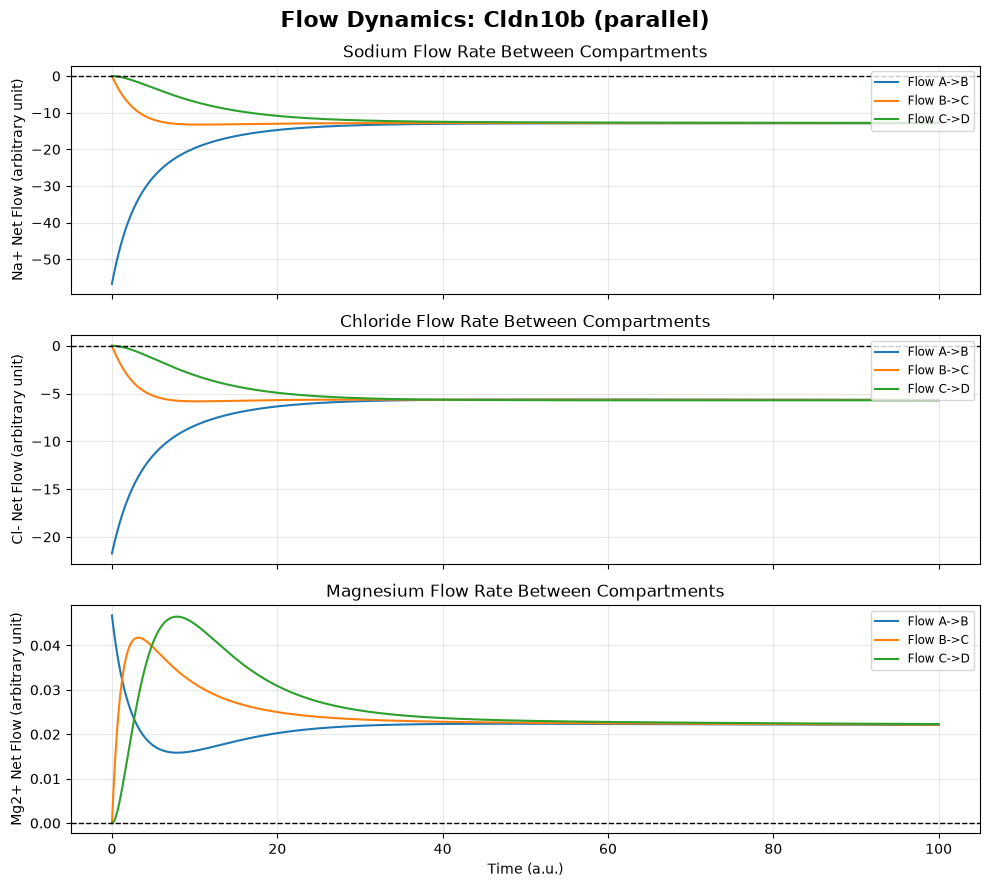

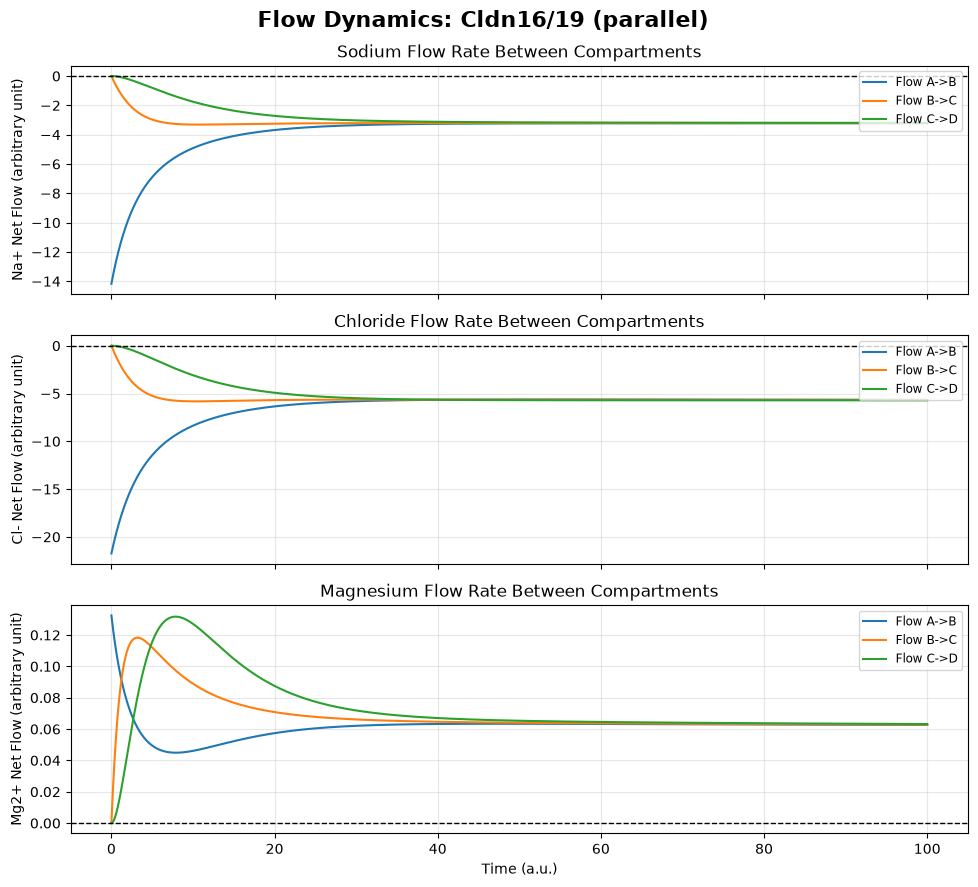

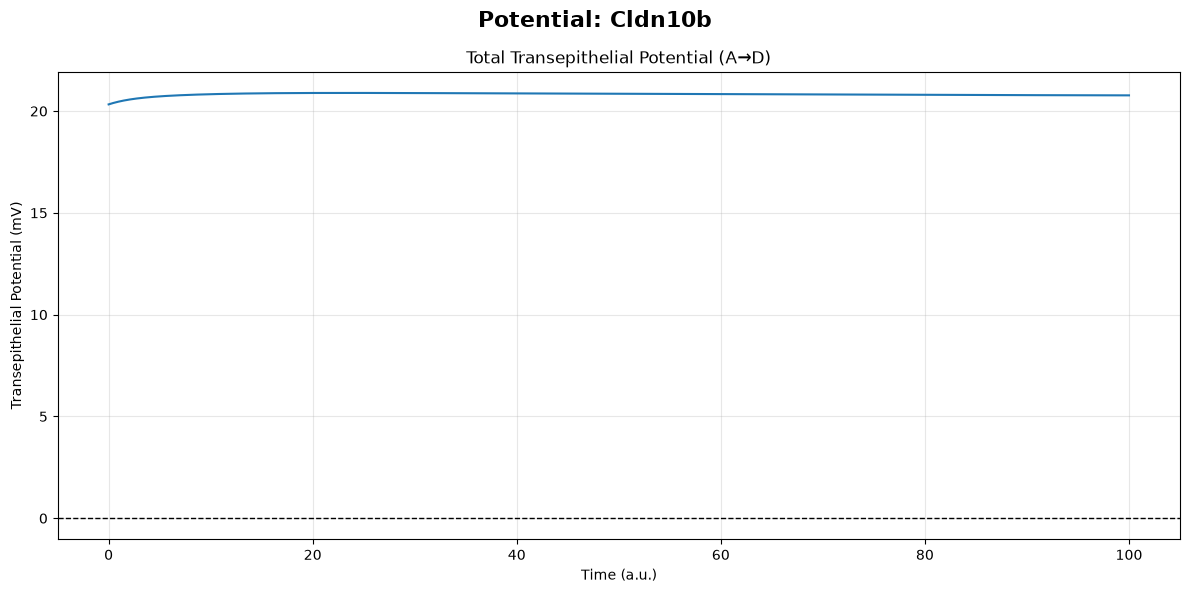

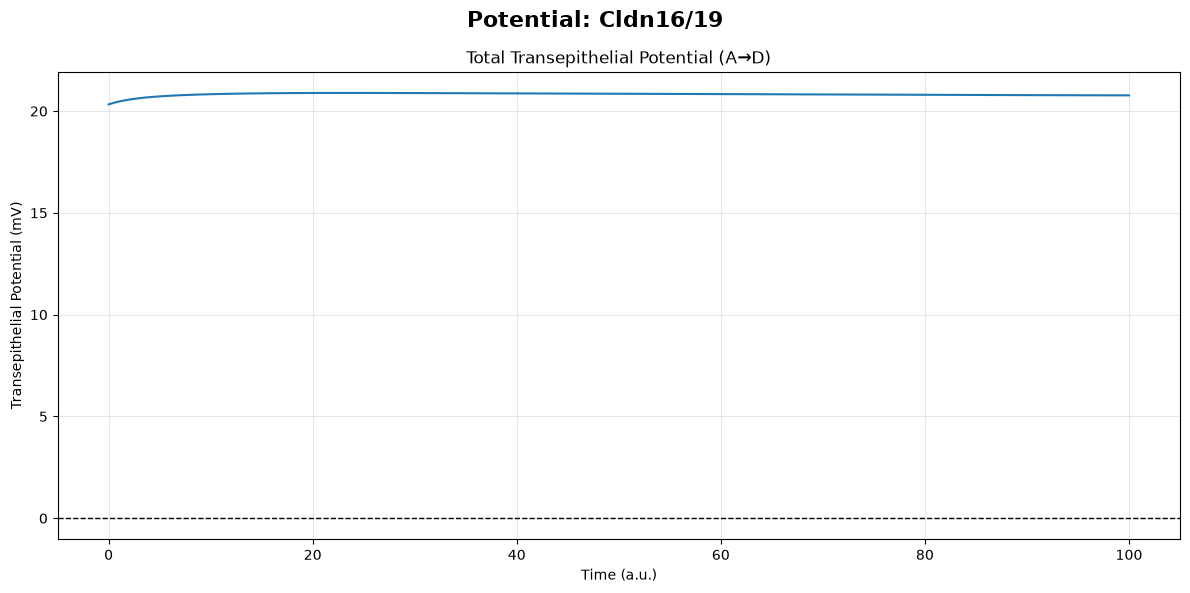

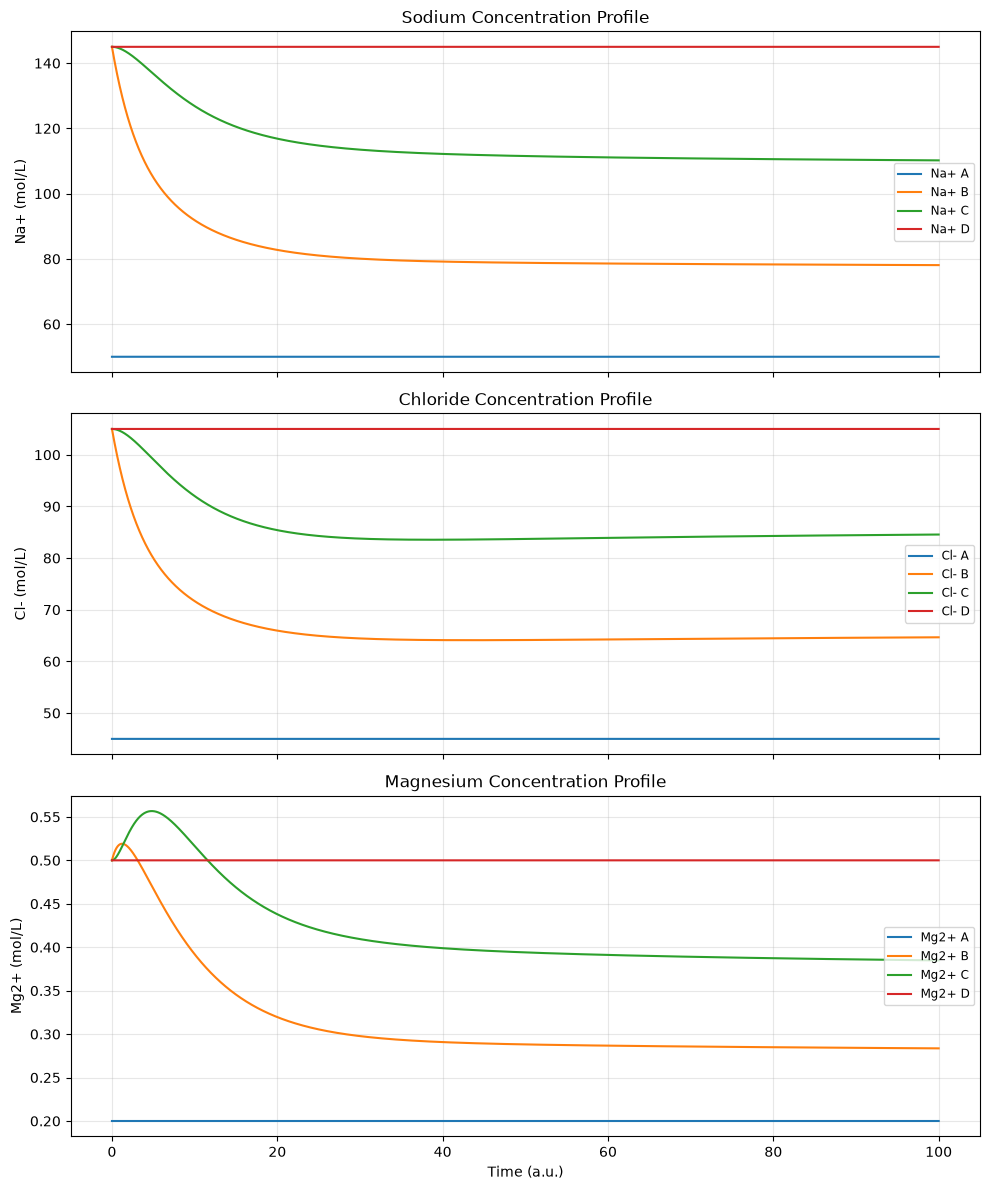

In [ ]:
# Plotting
if STATE == 1:
    plot_flow_dynamics(flow_history_10b, time_axis, title="Flow Dynamics: State 1 Cldn10b")
    plot_membrane_potential(transepithelial_potential, time_axis, title="Potential: State 1")

elif STATE == 2:
    if SIMULATION_MODE == "parallel":
        plot_flow_dynamics(flow_history_10b, time_axis, title="Flow Dynamics: Cldn10b (parallel)")
        plot_flow_dynamics(flow_history_16_19, time_axis, title="Flow Dynamics: Cldn16/19 (parallel)")
        plot_membrane_potential(transepithelial_potential_10b, time_axis, title="Potential: Cldn10b")
        plot_membrane_potential(transepithelial_potential_16_19, time_axis, title="Potential: Cldn16/19")

    elif SIMULATION_MODE == "avg":
        plot_flow_dynamics(flow_history_avg, time_axis, title="Flow Dynamics: Averaged * 2")
        plot_membrane_potential(transepithelial_potential_avg, time_axis, title="Potential: Averaged")

plot_ion_dynamics(history, time_axis)    

Research Question: Is the sum of the ion fluxes through the combined system larger than 2 times the flux through the AVG system (assuming that half of the junctions are 10b, half are 16/19)? Checked for Na+, Cl-, and Mg2+.

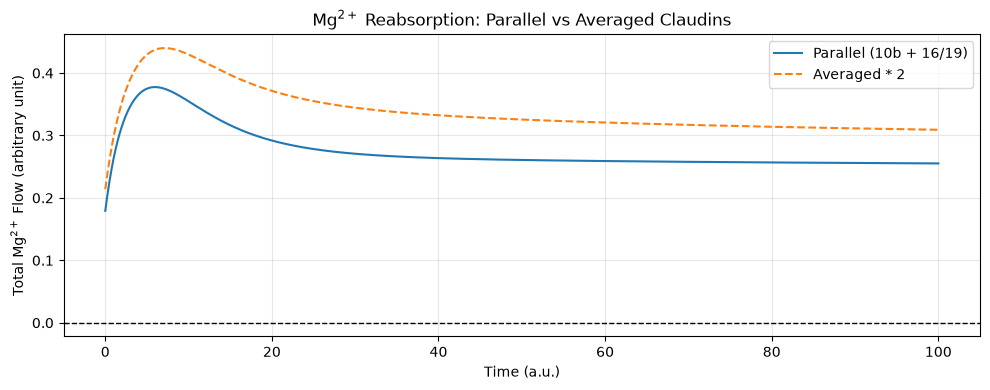

([0.17927991146062788,
  0.17929020058768025,
  0.17930048937400836,
  0.17931077781957516,
  0.17932106592434038,
  0.17933135368826708,
  0.1793416411113169,
  0.17935192819345103,
  0.17936221493463073,
  0.17937250133481905,
  0.17938278739397673,
  0.17939307311206626,
  0.1794033584890485,
  0.17941364352488606,
  0.17942392821954042,
  0.1794342125729738,
  0.1794444965851471,
  0.17945478025602327,
  0.1794650635855636,
  0.17947534657372988,
  0.17948562922048422,
  0.17949591152578906,
  0.1795061934896052,
  0.17951647511189572,
  0.179526756392622,
  0.17953703733174606,
  0.17954731792922984,
  0.1795575981850361,
  0.1795678780991259,
  0.17957815767146168,
  0.1795884369020057,
  0.17959871579071965,
  0.1796089943375657,
  0.17961927254250634,
  0.17962955040550324,
  0.17963982792651917,
  0.17965010510551577,
  0.17966038194245507,
  0.17967065843729974,
  0.179680934590012,
  0.17969121040055389,
  0.17970148586888762,
  0.17971176099497485,
  0.17972203577877954,
  

In [ ]:
def total_flow(flow_history, ion):
    """Sums flux for one ion across all junctions at each timestep."""
    n_steps = len(next(iter(flow_history.values()))[ion])
    return [sum(flow_history[j][ion][t] for j in flow_history) for t in range(n_steps)]


ION_LABELS = {'Na': 'Na$^+$', 'Cl': 'Cl$^-$', 'Mg': 'Mg$^{2+}$'}

def plot_total_flux_comparison(saved_parallel, saved_avg, ion='Mg'):
    """
    Compares total flux (summed across all junctions) between the parallel
    (Cldn10b + Cldn16/19) and averaged (single averaged claudin, doubled
    permeability) simulation modes, for the given ion ('Na', 'Cl', or 'Mg').
    """
    flow_10b, flow_16_19, time_axis = saved_parallel
    flow_avg, _ = saved_avg

    flux_parallel = [a + b for a, b in zip(
        total_flow(flow_10b, ion),
        total_flow(flow_16_19, ion)
    )]
    flux_avg = total_flow(flow_avg, ion)

    label = ION_LABELS.get(ion, ion)

    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, flux_parallel, label='Parallel (10b + 16/19)')
    plt.plot(time_axis, flux_avg,      label='Averaged * 2', linestyle='--')
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.ylabel(f'Total {label} Flow (arbitrary unit)')
    plt.xlabel('Time (a.u.)')
    plt.title(f'{label} Reabsorption: Parallel vs Averaged Claudins')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures/state_{STATE}_{ion.lower()}_comparison.png")
    plt.show()

    return flux_parallel, flux_avg


# Backwards-compatible alias for the Mg-specific research question above
def plot_mg_comparison(saved_parallel, saved_avg):
    return plot_total_flux_comparison(saved_parallel, saved_avg, ion='Mg')

# Call only once both modes have been run! e.g.:
plot_total_flux_comparison(saved_parallel, saved_avg, ion='Mg')
# plot_total_flux_comparison(saved_parallel, saved_avg, ion='Na')
# plot_total_flux_comparison(saved_parallel, saved_avg, ion='Cl')

The parallel model consistently shows higher Mg2+ reabsorption than the averaged model throughout the simulation. (The difference became larger when calculating with shared potential)



to check what causes the reabsorption difference - because equal total permeabilities makes it very confusing -, check sodium flux, potential values, test what happens if 10b and 1619 where the same as avg


avg potential: 22.45 mV
parallel potential: 24.12 mV

sodium and potential comparisons show only a small gap between the avg and parallel. The high difference between the Magnesium comparison comes from its divalence and therefore amplified effect. 